# Cross-case 2D--3D particle heterogeneity by particle type


In [38]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import json
import importlib
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/compare_particle_heterogeneity.ipynb
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
PARCELS_DIR = PROJECT_DIR / "z.parcels_postprocessing"
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

PARCELS_RESULTS_ROOT = (PARCELS_DIR / "results").resolve()
FLOW_RESULTS_ROOT = (FLOW_DIR / "results").resolve()

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR, PARCELS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(shu)
shu.apply_plot_style()


def apply_cross_case_style():
    """Use the exact font sizing applied in the activity comparison."""
    shu.apply_plot_style()
    plt.rcParams.update({
        "font.size": max(getattr(ptheme, "FONT_SIZE", 14), 19),
        "axes.titlesize": max(getattr(ptheme, "TITLE_SIZE", 20), 24),
        "axes.labelsize": max(getattr(ptheme, "LABEL_SIZE", 18), 22),
        "xtick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 18),
        "ytick.labelsize": max(getattr(ptheme, "TICK_SIZE", 16), 18),
        "legend.fontsize": max(getattr(ptheme, "LEGEND_SIZE", 15), 17),
        "figure.titlesize": max(getattr(ptheme, "SUPTITLE_SIZE", 24), 27),
    })


apply_cross_case_style()

print(f"Notebook dir        : {NB_DIR}")
print(f"Particle results    : {PARCELS_RESULTS_ROOT}")
print(f"Flow results        : {FLOW_RESULTS_ROOT}")


Notebook dir        : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Particle results    : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results
Flow results        : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results


In [39]:
# ============================================================
# 2. USER SETTINGS
# ============================================================

CASE_NAMES = [
    "run_aug1", "run_aug1_f1", "run_aug1_f2", "run_aug2", "run_aug3",
    "run_dec1", "run_dec2", "run_feb1", "run_jan1", "run_jul1",
    "run_jun1", "run_mar1", "run_may1", "run_nov1", "run_oct1", "run_sep1",
]

HETEROGENEITY_CACHE_FILENAME = (
    "particle_heterogeneity_2D_vs_3D_selected_snapshots.nc"
)


COLOR_VARIABLE = "epsilon_proxy_m2_s3"
COLOR_SCALE = "auto"                 # "auto", "linear", or "log"
COLOR_MAP = "viridis"

COLOR_LABELS = {
    "glorys_mld_median_m": "GLORYS median MLD [m]",
    "mld_median_m": "MITgcm median MLD [m]",
    "epsilon_proxy_m2_s3": r"$\epsilon$ proxy [m$^2$ s$^{-3}$]",
    "eke_mean_m2_s2": r"Mean EKE [m$^2$ s$^{-2}$]",
    "Ri_b_median": r"Median bulk $Ri_b$",
    "divergence_rms_selected_snapshots_s-1":
        r"RMS divergence [s$^{-1}$]",
}

HETEROGENEITY_AXIS_SCALE = "linear"
HETEROGENEITY_LIMITS = None
MARKERS = ["o", "s", "^", "D"]
SAVE_FIGURES = True
SAVE_SUMMARY_CSV = True
SKIP_MISSING_CASES = True

OUTPUT_DIR = (
    PARCELS_RESULTS_ROOT
    / "_comparisons"
    / "cross_case_particle_heterogeneity"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV_PATH = (
    OUTPUT_DIR
    / f"particle_heterogeneity_2D_vs_3D_{COLOR_VARIABLE.replace('.', '_')}.csv"
)

print(f"Colour variable : {COLOR_VARIABLE}")
print(f"Output directory: {OUTPUT_DIR}")


Colour variable : epsilon_proxy_m2_s3
Output directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_heterogeneity


In [40]:
# ============================================================
# 3. LOAD THE COMPACT CACHES
# ============================================================

def nested(mapping, key):
    value = mapping
    for part in key.split("."):
        value = value[part]
    return value


def text(value):
    return value.decode("utf-8") if isinstance(value, bytes) else str(value)


def particle_type(label):
    label = " ".join(text(label).lower().split())
    if "passive" in label:
        return "Passive particles"
    if "gdp" in label and "drifter" in label:
        return "GDP drifter"
    if "megaplastic" in label:
        return "Simple megaplastic"
    return None


def load_characterization(case_name, ds):
    # Prefer the current JSON in the 3D result directory, because it may have
    # been updated after the heterogeneity cache was written.
    path = FLOW_RESULTS_ROOT / case_name / f"{case_name}_domain_characterization.json"
    if path.exists():
        with path.open(encoding="utf-8") as handle:
            return json.load(handle)

    return json.loads(ds.attrs.get("domain_characterization_json", "{}"))


def snapshot_color(characterization, variable, obs_index):
    value = nested(characterization, variable)
    if isinstance(value, dict):
        value = value[str(int(obs_index))]
    return float(value)


def load_case(case_name):
    cache = (
        FLOW_RESULTS_ROOT / case_name / "metrics"
        / HETEROGENEITY_CACHE_FILENAME
    )
    if not cache.exists():
        raise FileNotFoundError(cache)

    with xr.open_dataset(cache) as ds_open:
        ds = ds_open.load()

    characterization = load_characterization(case_name, ds)
    rows = []

    for p in range(ds.sizes["particle_class"]):
        labels = [
            text(ds[name].values[p])
            for name in (
                "particle_panel_label",
                "source_particle_label_3d",
                "source_particle_label_2d",
                "particle_key",
            )
            if name in ds
        ]
        label = next((value for value in labels if value), f"particle_{p}")
        group = particle_type(label)
        if group is None:
            continue

        for s, day in enumerate(ds["target_time_days_3d"].values):
            obs = int(ds["requested_obs_index_3d"].values[s])
            rows.append({
                "case_3d": case_name,
                "particle_type": group,
                "particle_label": label,
                "time_days": float(day),
                "obs_index": obs,
                "heterogeneity_2d": float(ds["heterogeneity_2d"].values[p, s]),
                "heterogeneity_3d": float(ds["heterogeneity_3d"].values[p, s]),
                "color_value": snapshot_color(
                    characterization, COLOR_VARIABLE, obs
                ),
            })

    return rows


records, skipped = [], []
for case_name in CASE_NAMES:
    try:
        case_rows = load_case(case_name)
        records.extend(case_rows)
        print(f"Loaded {case_name}: {len(case_rows)} points")
    except Exception as exc:
        if not SKIP_MISSING_CASES:
            raise
        skipped.append(f"{case_name}: {type(exc).__name__}: {exc}")
        warnings.warn(skipped[-1])

comparison_df = pd.DataFrame(records)
if comparison_df.empty:
    raise RuntimeError("No heterogeneity data were loaded.")

comparison_df = comparison_df.sort_values(
    ["particle_type", "case_3d", "time_days"]
).reset_index(drop=True)

display(comparison_df)

if SAVE_SUMMARY_CSV:
    comparison_df.to_csv(SUMMARY_CSV_PATH, index=False)
    print(f"Saved: {SUMMARY_CSV_PATH}")


Loaded run_aug1: 12 points
Loaded run_aug1_f1: 12 points
Loaded run_aug1_f2: 12 points
Loaded run_aug2: 12 points
Loaded run_aug3: 12 points
Loaded run_dec1: 12 points
Loaded run_dec2: 12 points
Loaded run_feb1: 12 points
Loaded run_jan1: 12 points
Loaded run_jul1: 12 points
Loaded run_jun1: 12 points
Loaded run_mar1: 12 points
Loaded run_may1: 12 points
Loaded run_nov1: 12 points
Loaded run_oct1: 12 points
Loaded run_sep1: 12 points


,case_3d,particle_type,particle_label,time_days,obs_index,heterogeneity_2d,heterogeneity_3d,color_value
0,run_aug1,GDP drifter,"Simple GDP drifter, St=3.313e-03",0.0,0,1.031369,1.031224,3.186072e-09
1,run_aug1,GDP drifter,"Simple GDP drifter, St=3.313e-03",3.0,24,1.022448,1.166434,3.186072e-09
2,run_aug1,GDP drifter,"Simple GDP drifter, St=3.313e-03",7.0,56,1.022830,1.453845,3.186072e-09
3,run_aug1,GDP drifter,"Simple GDP drifter, St=3.313e-03",13.0,104,1.052250,1.802133,3.186072e-09
4,run_aug1_f1,GDP drifter,"Simple GDP drifter, St=6.438e-03",0.0,0,1.031229,1.031283,3.991959e-09
...,...,...,...,...,...,...,...,...
187,run_oct1,Simple megaplastic,"Simple megaplastic, St=2.894e-02",13.0,104,1.100814,1.429977,1.036627e-09
188,run_sep1,Simple megaplastic,"Simple megaplastic, St=4.615e-02",0.0,0,1.031265,1.031419,1.950092e-09
189,run_sep1,Simple megaplastic,"Simple megaplastic, St=4.615e-02",3.0,24,1.041820,1.125217,1.950092e-09
190,run_sep1,Simple megaplastic,"Simple megaplastic, St=4.615e-02",7.0,56,1.059017,1.377894,1.950092e-09


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_heterogeneity\particle_heterogeneity_2D_vs_3D_epsilon_proxy_m2_s3.csv


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_heterogeneity\particle_heterogeneity_2D_vs_3D_passive_particles_epsilon_proxy_m2_s3.png


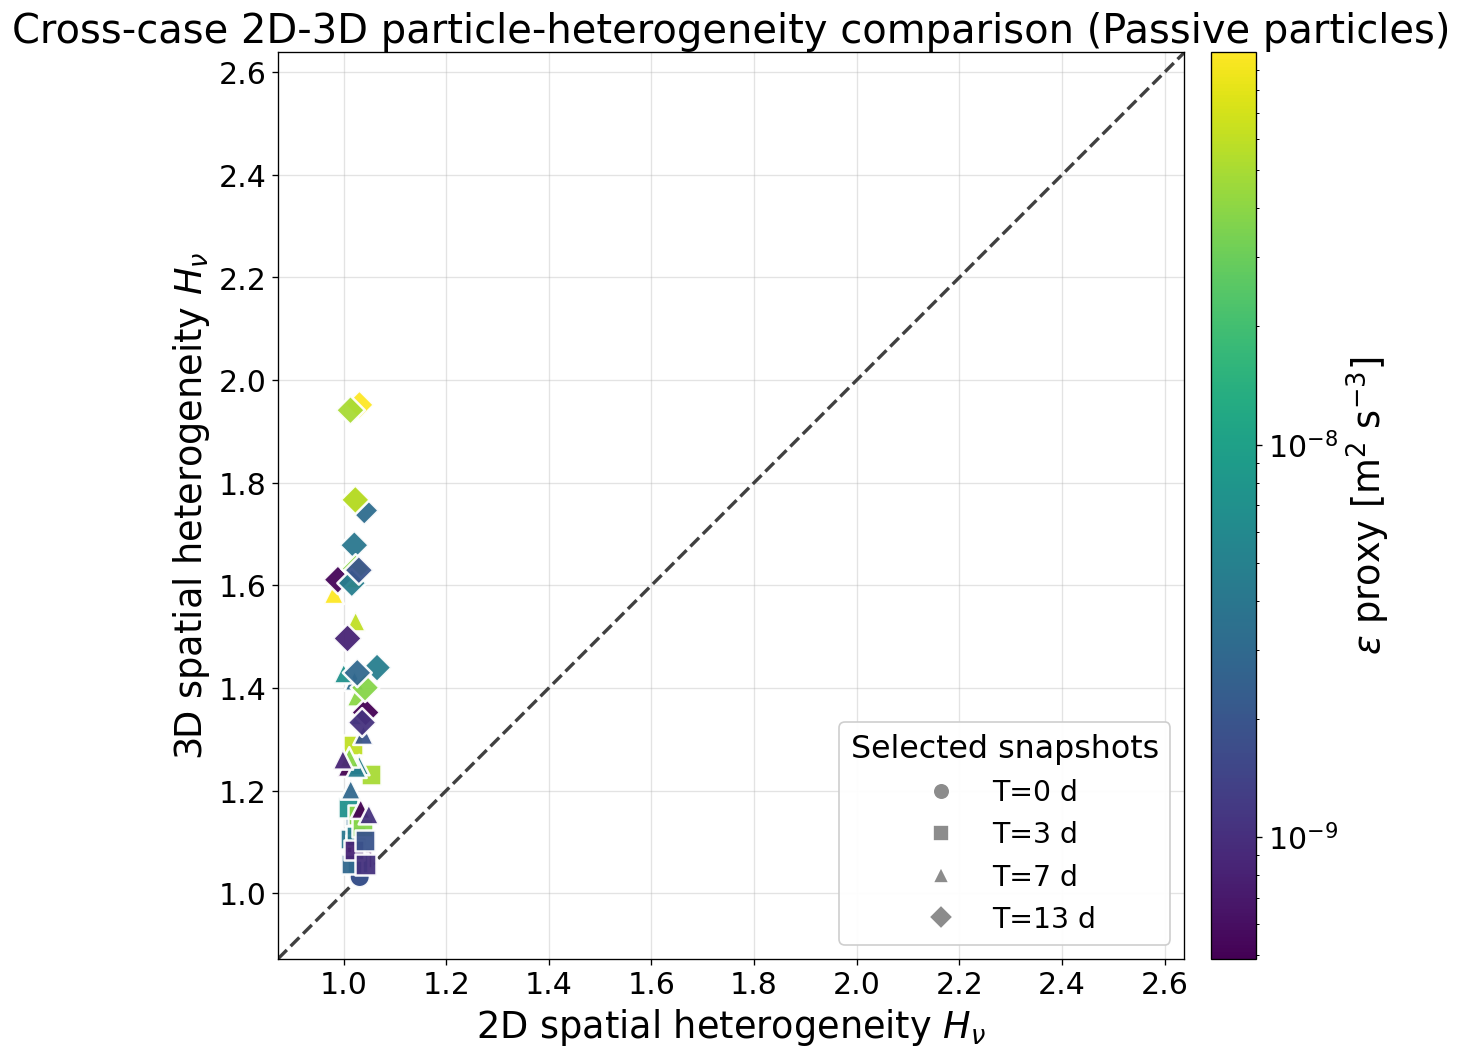

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_heterogeneity\particle_heterogeneity_2D_vs_3D_gdp_drifter_epsilon_proxy_m2_s3.png


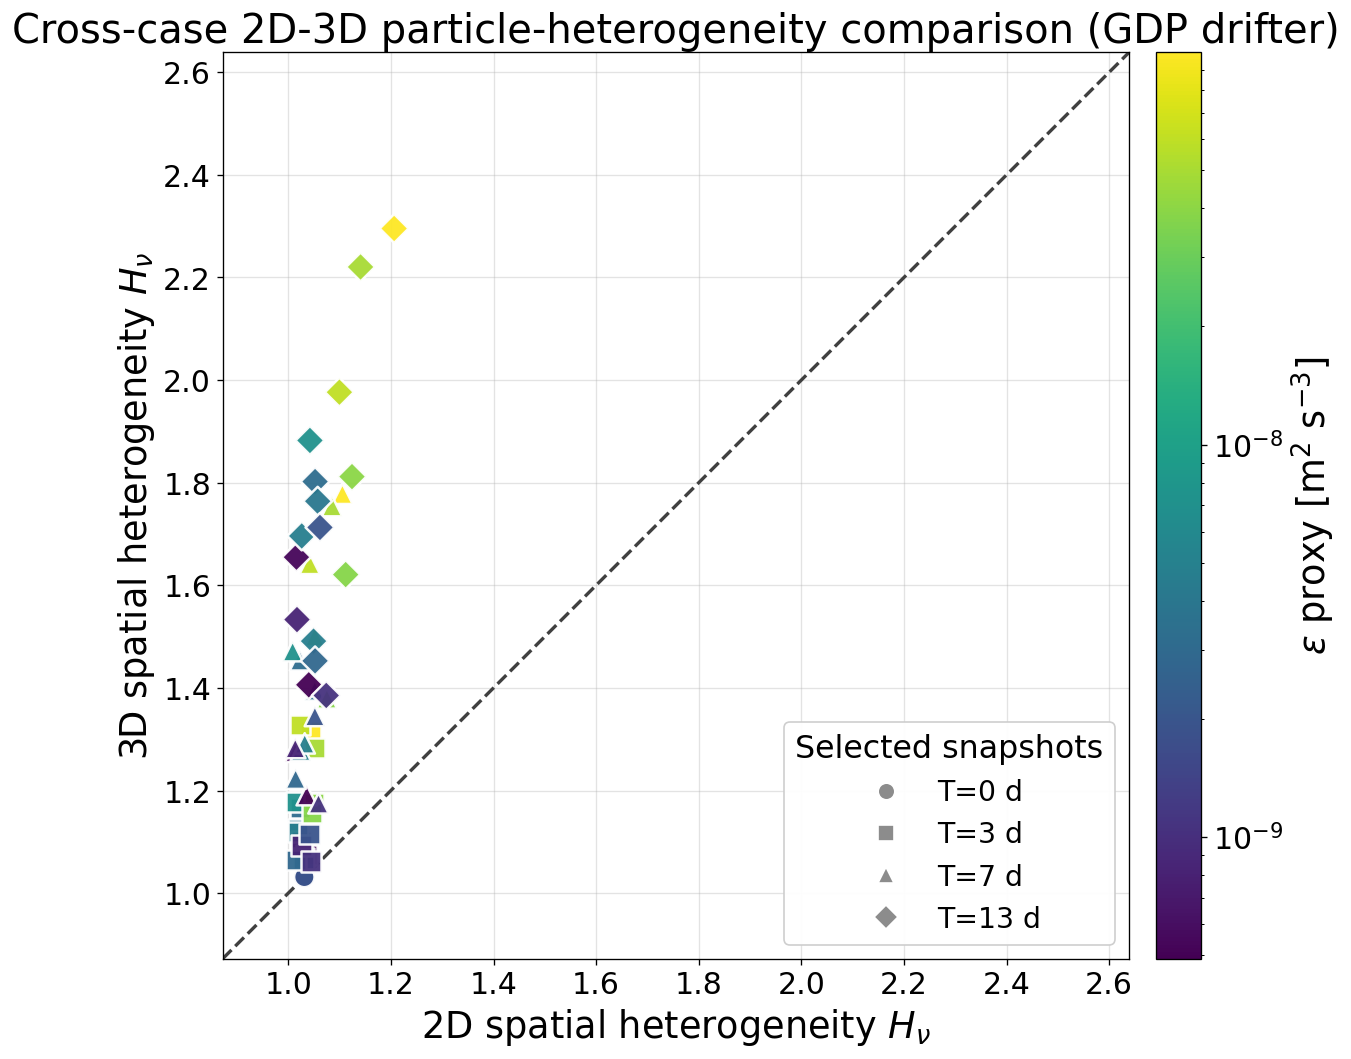

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\_comparisons\cross_case_particle_heterogeneity\particle_heterogeneity_2D_vs_3D_simple_megaplastic_epsilon_proxy_m2_s3.png


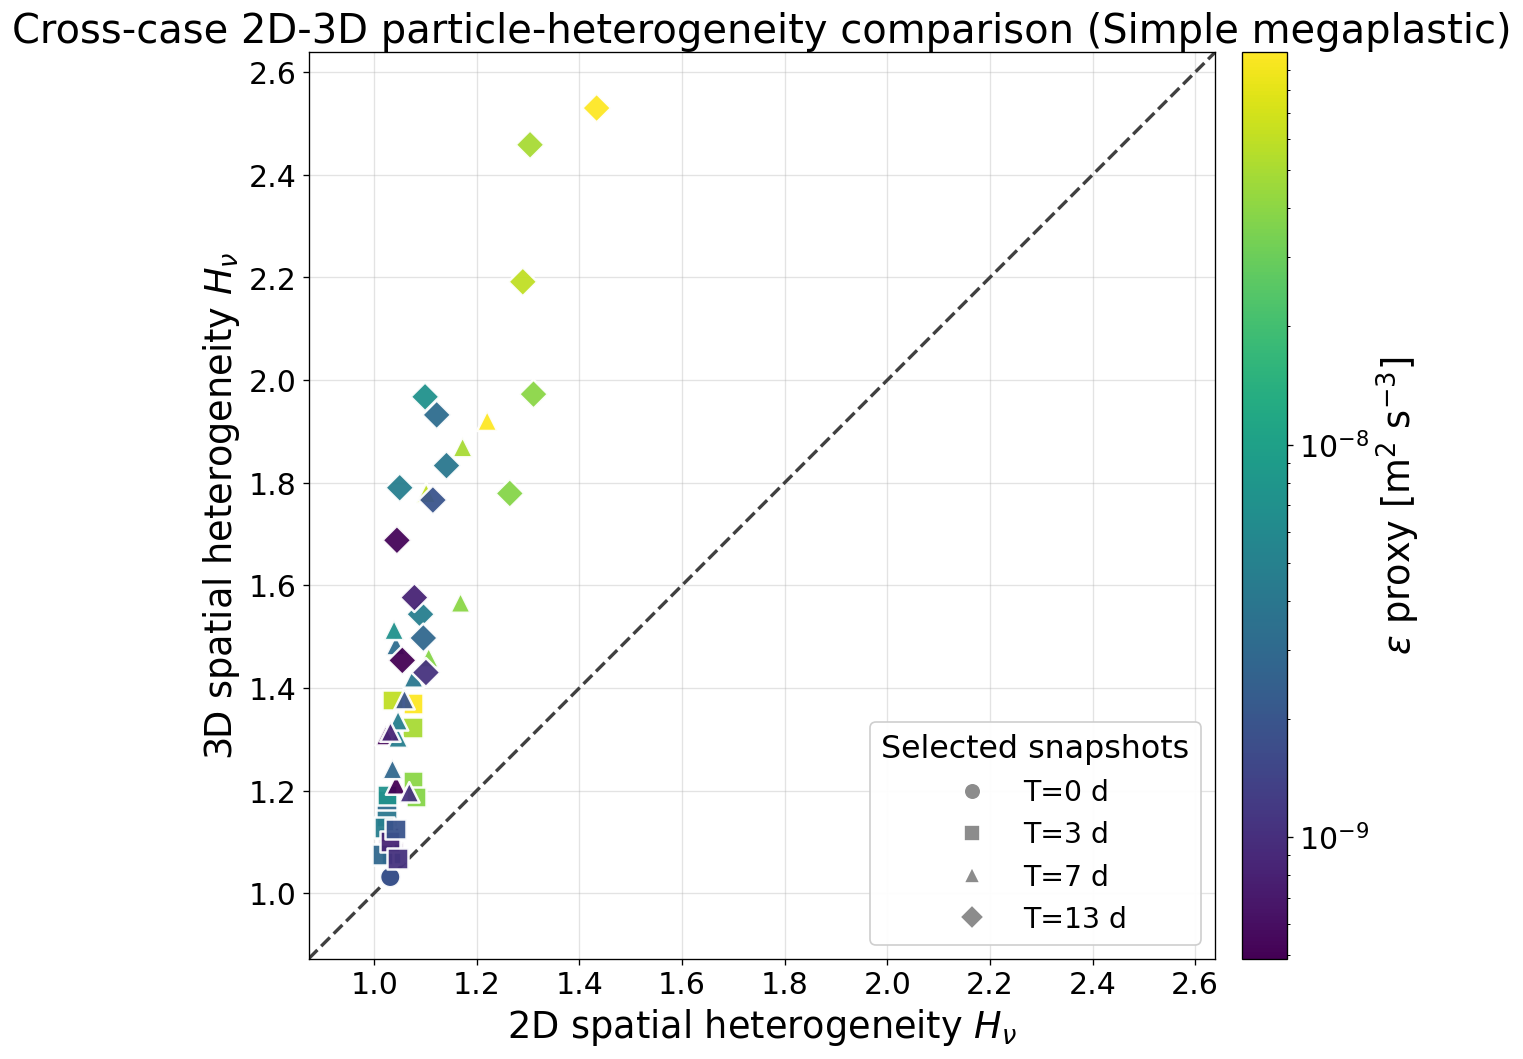

In [41]:
# ============================================================
# 4. ONE CROSS-CASE FIGURE PER PARTICLE TYPE
# ============================================================

def color_norm(values):
    values = np.asarray(values, dtype=float)
    scale = COLOR_SCALE
    if scale == "auto":
        scale = (
            "log"
            if any(token in COLOR_VARIABLE.lower()
                   for token in ("epsilon", "eke", "ri_", "divergence"))
            else "linear"
        )

    lo, hi = float(values.min()), float(values.max())
    if np.isclose(lo, hi):
        lo, hi = lo / 1.01, hi * 1.01

    return LogNorm(lo, hi) if scale == "log" else Normalize(lo, hi)


def axis_limits(data):
    if HETEROGENEITY_LIMITS is not None:
        return tuple(map(float, HETEROGENEITY_LIMITS))

    values = np.r_[
        data["heterogeneity_2d"].to_numpy(float),
        data["heterogeneity_3d"].to_numpy(float),
    ]
    lo, hi = float(np.nanmin(values)), float(np.nanmax(values))

    if HETEROGENEITY_AXIS_SCALE == "log":
        factor = np.exp(0.06 * np.log(hi / lo))
        return lo / factor, hi * factor

    pad = 0.07 * (hi - lo)
    return lo - pad, hi + pad


def slug(value):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", value).strip("_").lower()


finite = np.isfinite(
    comparison_df[["heterogeneity_2d", "heterogeneity_3d", "color_value"]]
).all(axis=1)
plot_df = comparison_df.loc[finite].copy()

norm = color_norm(plot_df["color_value"])
limits = axis_limits(plot_df)
cmap = plt.get_cmap(COLOR_MAP)

figures = {}
for group in ("Passive particles", "GDP drifter", "Simple megaplastic"):
    data = plot_df[plot_df["particle_type"] == group]
    if data.empty:
        warnings.warn(f"No data found for {group}.")
        continue

    apply_cross_case_style()
    fig, ax = plt.subplots(figsize=(10.8, 9.2), facecolor="white")
    days = sorted(data["time_days"].unique())
    marker_by_day = {day: MARKERS[i] for i, day in enumerate(days)}

    for day in days:
        subset = data[data["time_days"] == day]
        ax.scatter(
            subset["heterogeneity_2d"],
            subset["heterogeneity_3d"],
            c=subset["color_value"],
            cmap=cmap,
            norm=norm,
            marker=marker_by_day[day],
            s=150,
            edgecolors="white",
            linewidths=1.5,
            alpha=0.95,
            zorder=3,
        )

    line = (
        np.geomspace(*limits, 300)
        if HETEROGENEITY_AXIS_SCALE == "log"
        else np.linspace(*limits, 300)
    )
    ax.plot(
        line, line, "--",
        color=shu.get_color("reference"),
        lw=2.0,
        zorder=2,
    )

    ax.set(
        xscale=HETEROGENEITY_AXIS_SCALE,
        yscale=HETEROGENEITY_AXIS_SCALE,
        xlim=limits,
        ylim=limits,
        xlabel=r"2D spatial heterogeneity $H_\nu$",
        ylabel=r"3D spatial heterogeneity $H_\nu$",
        title=f"Cross-case 2D-3D particle-heterogeneity comparison ({group})",
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)

    ax.legend(
        handles=[
            Line2D(
                [0], [0],
                marker=marker_by_day[day],
                linestyle="none",
                markerfacecolor="0.55",
                markeredgecolor="white",
                markersize=10,
                label=f"T={day:g} d",
            )
            for day in days
        ],
        loc="lower right",
        frameon=True,
        framealpha=0.95,
        title="Selected snapshots",
    )

    colorbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        pad=0.025,
        fraction=0.05,
    )
    colorbar.set_label(COLOR_LABELS.get(COLOR_VARIABLE, COLOR_VARIABLE))
    fig.tight_layout()

    if SAVE_FIGURES:
        path = (
            OUTPUT_DIR
            / f"particle_heterogeneity_2D_vs_3D_{slug(group)}_"
              f"{COLOR_VARIABLE.replace('.', '_')}.png"
        )
        fig.savefig(
            path,
            dpi=getattr(ptheme, "SAVE_DPI", 300),
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"Saved: {path}")

    plt.show()
    figures[group] = (fig, ax)
